In [1]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'data_dictionary.csv', 'ev_battery_failure_dataset.csv', 'EV_ML_Model.ipynb', 'feature_descriptions.md', 'venv']


In [2]:
import pandas as pd

df = pd.read_csv("ev_battery_failure_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (200000, 70)

Columns:
['vehicle_id', 'vehicle_brand', 'vehicle_model', 'vehicle_type', 'manufacturing_year', 'battery_manufacturer', 'battery_chemistry', 'battery_capacity_kwh', 'drive_type', 'odometer_km', 'vehicle_age_years', 'fleet_or_private', 'battery_serial', 'cycle_count', 'battery_health_percent', 'state_of_charge', 'depth_of_discharge', 'state_of_health', 'cell_voltage_avg', 'cell_voltage_std', 'pack_voltage', 'cell_temperature_avg', 'cell_temperature_max', 'internal_resistance', 'charge_efficiency', 'discharge_efficiency', 'remaining_capacity', 'capacity_loss_percent', 'charging_cycles_last_month', 'fast_charge_ratio', 'slow_charge_ratio', 'average_charge_power_kw', 'average_charging_time', 'overnight_charging_ratio', 'home_charging_ratio', 'charging_interruptions', 'overcharge_events', 'average_speed', 'average_trip_distance', 'aggressive_acceleration_score', 'hard_braking_score', 'regenerative_braking_usage', 'highway_driving_ratio', 'ci

In [3]:
print("Battery Failure Distribution:")
print(df["battery_failure"].value_counts())

print("\nPercentage:")
print(df["battery_failure"].value_counts(normalize=True) * 100)

print("\nData Types:")
print(df.dtypes)

Battery Failure Distribution:
battery_failure
0    180079
1     19921
Name: count, dtype: int64

Percentage:
battery_failure
0    90.0395
1     9.9605
Name: proportion, dtype: float64

Data Types:
vehicle_id                          object
vehicle_brand                       object
vehicle_model                       object
vehicle_type                        object
manufacturing_year                 float64
                                    ...   
thermal_health_score               float64
charging_quality_score             float64
driving_stress_score               float64
predicted_remaining_life_cycles    float64
battery_failure                      int64
Length: 70, dtype: object


In [4]:
print("Unique values in important columns:")

check_columns = [
    "battery_failure",
    "predicted_remaining_life_cycles",
    "thermal_runaway_risk",
    "aging_score",
    "thermal_health_score",
    "charging_quality_score",
    "driving_stress_score",
    "previous_faults",
    "BMS_warning_count",
    "abnormal_voltage_events",
    "battery_stress_index"
]

for column in check_columns:
    print("\n", column)
    print("Unique:", df[column].nunique())
    print(df[column].describe())

Unique values in important columns:

 battery_failure
Unique: 2
count    200000.000000
mean          0.099605
std           0.299473
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: battery_failure, dtype: float64

 predicted_remaining_life_cycles
Unique: 5169
count    191026.000000
mean       1859.485986
std        1834.356925
min           0.000000
25%         891.000000
50%        1245.000000
75%        3085.000000
max       15474.000000
Name: predicted_remaining_life_cycles, dtype: float64

 thermal_runaway_risk
Unique: 1000
count    192794.000000
mean         47.341085
std          18.532210
min           0.000000
25%          30.700000
50%          51.100000
75%          60.100000
max         100.000000
Name: thermal_runaway_risk, dtype: float64

 aging_score
Unique: 1001
count    191635.000000
mean         29.912538
std          28.011328
min           0.000000
25%           6.900000
50%          22.600000
7

In [5]:
data_dictionary = pd.read_csv("data_dictionary.csv")

print(data_dictionary.to_string(index=False))

                    column_name            category          data_type                                                                     description                                                                                            example_range_or_values  missing_pct
                     vehicle_id Vehicle Information categorical/string                                      Unique identifier for each vehicle record.                                 EV100000, EV100001, EV100002, EV100003, EV100004, EV100005, EV100006, EV100007 ...         0.00
                  vehicle_brand Vehicle Information categorical/string                        Manufacturer/brand of the electric vehicle (~20 brands).                                                                  Audi, BMW, BYD, Ford, GM, Honda, Hyundai, Kia ...         3.22
                  vehicle_model Vehicle Information categorical/string                                           Specific model name within the brand.             

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

features = [
    "manufacturing_year",
    "battery_capacity_kwh",
    "odometer_km",
    "vehicle_age_years",
    "cycle_count",
    "battery_health_percent",
    "state_of_charge",
    "depth_of_discharge",
    "state_of_health",
    "cell_voltage_avg",
    "cell_voltage_std",
    "pack_voltage",
    "cell_temperature_avg",
    "cell_temperature_max",
    "internal_resistance",
    "charge_efficiency",
    "discharge_efficiency",
    "remaining_capacity",
    "capacity_loss_percent",
    "charging_cycles_last_month",
    "fast_charge_ratio",
    "average_charge_power_kw",
    "average_charging_time",
    "charging_interruptions",
    "overcharge_events",
    "average_speed",
    "average_trip_distance",
    "aggressive_acceleration_score",
    "hard_braking_score",
    "regenerative_braking_usage",
    "highway_driving_ratio",
    "city_driving_ratio",
    "daily_distance",
    "average_ambient_temperature",
    "maximum_temperature",
    "minimum_temperature",
    "humidity",
    "altitude",
    "dust_exposure",
    "last_service_days",
    "cooling_system_health",
    "firmware_updates",
    "previous_faults",
    "maintenance_score",
    "thermal_runaway_risk",
    "voltage_imbalance",
    "temperature_variance",
    "sensor_fault_count",
    "BMS_warning_count",
    "abnormal_voltage_events",
    "battery_stress_index",
    "aging_score",
    "thermal_health_score",
    "charging_quality_score",
    "driving_stress_score"
]

df["vehicle_brand"] = df["vehicle_brand"].fillna("Unknown")
df["vehicle_model"] = df["vehicle_model"].fillna("Unknown")

brand_encoder = LabelEncoder()
model_encoder = LabelEncoder()

df["vehicle_brand_encoded"] = brand_encoder.fit_transform(df["vehicle_brand"])
df["vehicle_model_encoded"] = model_encoder.fit_transform(df["vehicle_model"])

features.append("vehicle_brand_encoded")
features.append("vehicle_model_encoded")

X = df[features]
y = df["battery_failure"]

print("Number of features:", len(features))
print("X shape:", X.shape)
print("Target shape:", y.shape)

Number of features: 57
X shape: (200000, 57)
Target shape: (200000,)


In [7]:
print("Brand:", "vehicle_brand_encoded" in features)
print("Model:", "vehicle_model_encoded" in features)
print("Total:", len(features))

Brand: True
Model: True
Total: 57


In [8]:
print(features)

['manufacturing_year', 'battery_capacity_kwh', 'odometer_km', 'vehicle_age_years', 'cycle_count', 'battery_health_percent', 'state_of_charge', 'depth_of_discharge', 'state_of_health', 'cell_voltage_avg', 'cell_voltage_std', 'pack_voltage', 'cell_temperature_avg', 'cell_temperature_max', 'internal_resistance', 'charge_efficiency', 'discharge_efficiency', 'remaining_capacity', 'capacity_loss_percent', 'charging_cycles_last_month', 'fast_charge_ratio', 'average_charge_power_kw', 'average_charging_time', 'charging_interruptions', 'overcharge_events', 'average_speed', 'average_trip_distance', 'aggressive_acceleration_score', 'hard_braking_score', 'regenerative_braking_usage', 'highway_driving_ratio', 'city_driving_ratio', 'daily_distance', 'average_ambient_temperature', 'maximum_temperature', 'minimum_temperature', 'humidity', 'altitude', 'dust_exposure', 'last_service_days', 'cooling_system_health', 'firmware_updates', 'previous_faults', 'maintenance_score', 'thermal_runaway_risk', 'voltag

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (160000, 57)
Testing data: (40000, 57)
Training target: (160000,)
Testing target: (40000,)


In [10]:
print("Missing values in training data:")
print(X_train.isnull().sum().sum())

print("Missing values in testing data:")
print(X_test.isnull().sum().sum())

Missing values in training data:
352034
Missing values in testing data:
88040


In [11]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Missing values handled successfully!")
print("Training data shape:", X_train_imputed.shape)
print("Testing data shape:", X_test_imputed.shape)

Missing values handled successfully!
Training data shape: (160000, 57)
Testing data shape: (40000, 57)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Feature scaling completed!")
print("Training data:", X_train_scaled.shape)
print("Testing data:", X_test_scaled.shape)

Feature scaling completed!
Training data: (160000, 57)
Testing data: (40000, 57)


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
import time

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

start_time = time.time()

rf_model.fit(X_train_scaled, y_train)

rf_train_time = time.time() - start_time

start_time = time.time()

rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_prediction_time = time.time() - start_time

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_log_loss = log_loss(y_test, rf_prob)

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("Log Loss:", rf_log_loss)
print("Training Time:", rf_train_time, "seconds")
print("Prediction Time:", rf_prediction_time, "seconds")

Random Forest Results
Accuracy: 0.95745
Precision: 0.8565625
Recall: 0.6880020080321285
F1 Score: 0.7630846325167038
Log Loss: 0.09772617085990198
Training Time: 160.18899703025818 seconds
Prediction Time: 2.0495553016662598 seconds


Confusion Matrix:
[[35557   459]
 [ 1243  2741]]


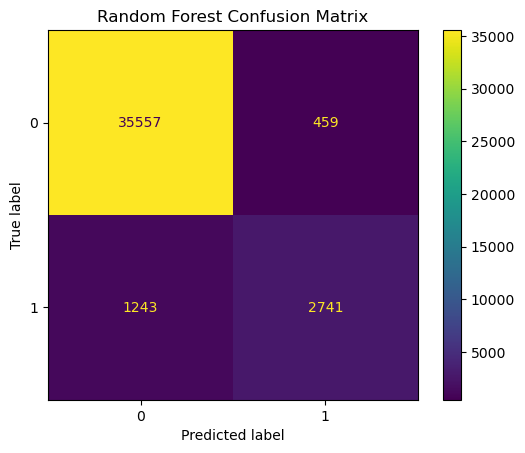

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf_cm = confusion_matrix(y_test, rf_pred)

print("Confusion Matrix:")
print(rf_cm)

ConfusionMatrixDisplay(confusion_matrix=rf_cm).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [15]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss
import time

et_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

start_time = time.time()

et_model.fit(X_train_scaled, y_train)

et_train_time = time.time() - start_time

start_time = time.time()

et_pred = et_model.predict(X_test_scaled)
et_prob = et_model.predict_proba(X_test_scaled)[:, 1]

et_prediction_time = time.time() - start_time

et_accuracy = accuracy_score(y_test, et_pred)
et_precision = precision_score(y_test, et_pred, zero_division=0)
et_recall = recall_score(y_test, et_pred, zero_division=0)
et_f1 = f1_score(y_test, et_pred, zero_division=0)
et_log_loss = log_loss(y_test, et_prob)

print("Extra Trees Results")
print("Accuracy:", et_accuracy)
print("Precision:", et_precision)
print("Recall:", et_recall)
print("F1 Score:", et_f1)
print("Log Loss:", et_log_loss)
print("Training Time:", et_train_time, "seconds")
print("Prediction Time:", et_prediction_time, "seconds")

Extra Trees Results
Accuracy: 0.959525
Precision: 0.8736176935229067
Recall: 0.6940261044176707
F1 Score: 0.7735347601063086
Log Loss: 0.09622269620327298
Training Time: 50.33087992668152 seconds
Prediction Time: 3.0103495121002197 seconds


Starting HistGradientBoosting training...
Training completed!
Training Time: 19.835794687271118 seconds

HISTGRADIENTBOOSTING RESULTS
Accuracy       : 0.96585
Precision      : 0.8453825857519789
Recall         : 0.8042168674698795
F1 Score       : 0.8242860818111655
Log Loss       : 0.07903870028492027
Training Time  : 19.835794687271118 seconds
Prediction Time: 1.489757776260376 seconds

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Healthy       0.98      0.98      0.98     36016
     Failure       0.85      0.80      0.82      3984

    accuracy                           0.97     40000
   macro avg       0.91      0.89      0.90     40000
weighted avg       0.97      0.97      0.97     40000


CONFUSION MATRIX
[[35430   586]
 [  780  3204]]


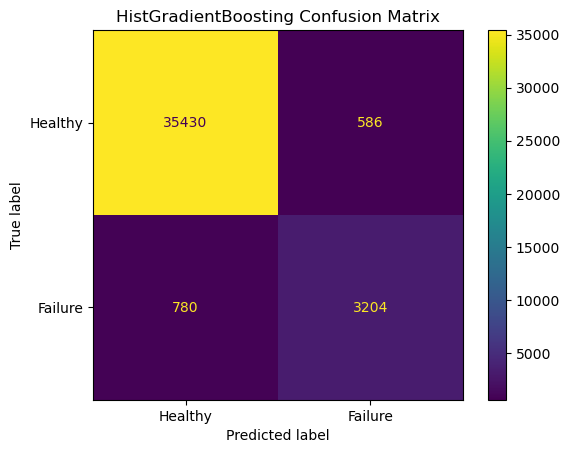

In [16]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt
import time

print("Starting HistGradientBoosting training...")

hgb_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42
)

train_start = time.time()

hgb_model.fit(X_train_imputed, y_train)

hgb_train_time = time.time() - train_start

print("Training completed!")
print("Training Time:", hgb_train_time, "seconds")

prediction_start = time.time()

hgb_pred = hgb_model.predict(X_test_imputed)

hgb_prob = hgb_model.predict_proba(X_test_imputed)[:, 1]

hgb_prediction_time = time.time() - prediction_start

hgb_accuracy = accuracy_score(y_test, hgb_pred)

hgb_precision = precision_score(
    y_test,
    hgb_pred,
    zero_division=0
)

hgb_recall = recall_score(
    y_test,
    hgb_pred,
    zero_division=0
)

hgb_f1 = f1_score(
    y_test,
    hgb_pred,
    zero_division=0
)

hgb_log_loss = log_loss(
    y_test,
    hgb_prob
)

print()
print("=" * 50)
print("HISTGRADIENTBOOSTING RESULTS")
print("=" * 50)

print("Accuracy       :", hgb_accuracy)
print("Precision      :", hgb_precision)
print("Recall         :", hgb_recall)
print("F1 Score       :", hgb_f1)
print("Log Loss       :", hgb_log_loss)
print("Training Time  :", hgb_train_time, "seconds")
print("Prediction Time:", hgb_prediction_time, "seconds")

print()
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)

print(
    classification_report(
        y_test,
        hgb_pred,
        target_names=["Healthy", "Failure"],
        zero_division=0
    )
)

hgb_cm = confusion_matrix(
    y_test,
    hgb_pred
)

print()
print("=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)

print(hgb_cm)

ConfusionMatrixDisplay(
    confusion_matrix=hgb_cm,
    display_labels=["Healthy", "Failure"]
).plot()

plt.title("HistGradientBoosting Confusion Matrix")
plt.show()

Building ANN model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,793 (69.50 KB)

 Trainable params: 17,793 (69.50 KB)

 Non-trainable params: 0 (0.00 B)


Starting ANN training...
Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.9517 - loss: 0.1151 - val_accuracy: 0.9609 - val_loss: 0.0875
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9619 - loss: 0.0898 - val_accuracy: 0.9637 - val_loss: 0.0834
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9635 - loss: 0.0851 - val_accuracy: 0.9649 - val_loss: 0.0815
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9652 - loss: 0.0827 - val_accuracy: 0.9650 - val_loss: 0.0808
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9658 - loss: 0.0804 - val_accuracy: 0.9656 - val_loss: 0.0806
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9665 - loss: 0.0792 - val_accuracy: 0.9655 - val_loss: 0.0801
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9666 - loss: 0.0779 - val_accuracy: 0.9656 - val_loss: 0.0808
Epoch 8/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9669 - 

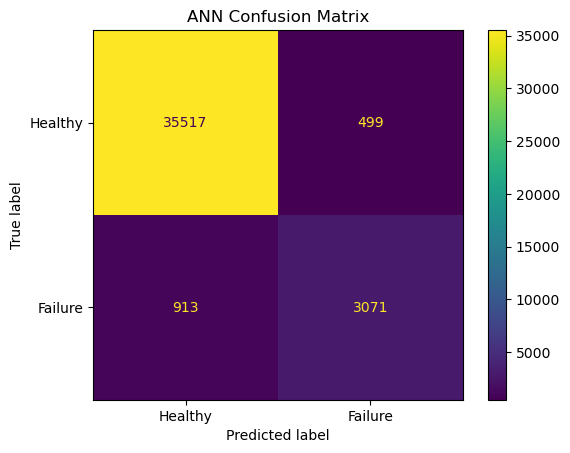

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import time

tf.random.set_seed(42)

print("Building ANN model...")

ann_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

print()
print("Starting ANN training...")

train_start = time.time()

history = ann_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

ann_train_time = time.time() - train_start

print()
print("ANN training completed!")
print("Training Time:", ann_train_time, "seconds")

prediction_start = time.time()

ann_prob = ann_model.predict(
    X_test_scaled,
    verbose=0
).ravel()

ann_pred = (ann_prob >= 0.5).astype(int)

ann_prediction_time = time.time() - prediction_start

ann_accuracy = accuracy_score(y_test, ann_pred)

ann_precision = precision_score(
    y_test,
    ann_pred,
    zero_division=0
)

ann_recall = recall_score(
    y_test,
    ann_pred,
    zero_division=0
)

ann_f1 = f1_score(
    y_test,
    ann_pred,
    zero_division=0
)

ann_log_loss = log_loss(
    y_test,
    ann_prob
)

ann_parameters = ann_model.count_params()

print()
print("=" * 55)
print("ANN RESULTS")
print("=" * 55)

print("Accuracy          :", ann_accuracy)
print("Precision         :", ann_precision)
print("Recall            :", ann_recall)
print("F1 Score          :", ann_f1)
print("Log Loss          :", ann_log_loss)
print("Training Time     :", ann_train_time, "seconds")
print("Prediction Time   :", ann_prediction_time, "seconds")
print("Trainable Params  :", ann_parameters)

print()
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)

print(
    classification_report(
        y_test,
        ann_pred,
        target_names=["Healthy", "Failure"],
        zero_division=0
    )
)

ann_cm = confusion_matrix(
    y_test,
    ann_pred
)

print()
print("=" * 55)
print("CONFUSION MATRIX")
print("=" * 55)

print(ann_cm)

ConfusionMatrixDisplay(
    confusion_matrix=ann_cm,
    display_labels=["Healthy", "Failure"]
).plot()

plt.title("ANN Confusion Matrix")
plt.show()

In [20]:
from IPython.display import display

final_results = results.copy()

final_results["Accuracy"] = final_results["Accuracy"].map(lambda x: f"{x:.2f}%")
final_results["Precision"] = final_results["Precision"].map(lambda x: f"{x:.2f}%")
final_results["Recall"] = final_results["Recall"].map(lambda x: f"{x:.2f}%")
final_results["F1 Score"] = final_results["F1 Score"].map(lambda x: f"{x:.2f}%")
final_results["Log Loss"] = final_results["Log Loss"].map(lambda x: f"{x:.4f}")
final_results["Training Time (s)"] = final_results["Training Time (s)"].map(lambda x: f"{x:.2f}")
final_results["Prediction Time (s)"] = final_results["Prediction Time (s)"].map(lambda x: f"{x:.2f}")

display(final_results.style
    .set_caption("Final Model Comparison")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("border", "1px solid black")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("width", "100%")
            ]
        }
    ])
)

,Model,Accuracy,Precision,Recall,F1 Score,Log Loss,Training Time (s),Prediction Time (s)
0,Random Forest,95.75%,85.66%,68.80%,76.31%,0.0977,160.19,2.05
1,Extra Trees,95.95%,87.36%,69.40%,77.35%,0.0962,50.33,3.01
2,HistGradientBoosting,96.58%,84.54%,80.42%,82.43%,0.0790,19.84,1.49
3,ANN,96.47%,86.02%,77.08%,81.31%,0.0887,259.07,5.79


In [21]:
import joblib
import os

os.makedirs("saved_model", exist_ok=True)

joblib.dump(
    hgb_model,
    "saved_model/hist_gradient_boosting_model.pkl"
)

joblib.dump(
    imputer,
    "saved_model/imputer.pkl"
)

joblib.dump(
    features,
    "saved_model/features.pkl"
)

print("Model and preprocessing files saved successfully!")
print()
print("saved_model/")
print("├── hist_gradient_boosting_model.pkl")
print("├── imputer.pkl")
print("└── features.pkl")

Model and preprocessing files saved successfully!

saved_model/
├── hist_gradient_boosting_model.pkl
├── imputer.pkl
└── features.pkl


In [22]:
import joblib
import pandas as pd

model = joblib.load(
    "saved_model/hist_gradient_boosting_model.pkl"
)

saved_imputer = joblib.load(
    "saved_model/imputer.pkl"
)

saved_features = joblib.load(
    "saved_model/features.pkl"
)

def predict_battery_failure(input_data):

    input_df = pd.DataFrame(
        [input_data],
        columns=saved_features
    )

    input_imputed = saved_imputer.transform(input_df)

    prediction = model.predict(input_imputed)[0]

    probability = model.predict_proba(input_imputed)[0][1]

    if prediction == 1:
        result = "Battery Failure Risk"
    else:
        result = "Battery Healthy"

    return {
        "prediction": int(prediction),
        "result": result,
        "failure_probability": float(probability)
    }

print("Prediction function created successfully!")

Prediction function created successfully!


In [23]:
sample_row = df[features].iloc[0].to_dict()

result = predict_battery_failure(sample_row)

print("Prediction Result")
print("=" * 40)
print("Prediction:", result["prediction"])
print("Status:", result["result"])
print("Failure Probability:", result["failure_probability"])

Prediction Result
Prediction: 0
Status: Battery Healthy
Failure Probability: 0.0005233687093844391


In [24]:
regression_target = "predicted_remaining_life_cycles"

X_reg = df[features]
y_reg = df[regression_target]

print("Regression target:", regression_target)
print("X shape:", X_reg.shape)
print("Y shape:", y_reg.shape)
print()
print("Target statistics:")
print(y_reg.describe())

Regression target: predicted_remaining_life_cycles
X shape: (200000, 57)
Y shape: (200000,)

Target statistics:
count    191026.000000
mean       1859.485986
std        1834.356925
min           0.000000
25%         891.000000
50%        1245.000000
75%        3085.000000
max       15474.000000
Name: predicted_remaining_life_cycles, dtype: float64


In [25]:
reg_df = df[features + [regression_target]].dropna(
    subset=[regression_target]
)

X_reg = reg_df[features]
y_reg = reg_df[regression_target]

print("Regression data prepared successfully!")
print("X shape:", X_reg.shape)
print("Y shape:", y_reg.shape)
print("Missing target values:", y_reg.isnull().sum())

Regression data prepared successfully!
X shape: (191026, 57)
Y shape: (191026,)
Missing target values: 0


In [26]:
from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Regression training data:", X_reg_train.shape)
print("Regression testing data:", X_reg_test.shape)
print("Regression training target:", y_reg_train.shape)
print("Regression testing target:", y_reg_test.shape)

Regression training data: (152820, 57)
Regression testing data: (38206, 57)
Regression training target: (152820,)
Regression testing target: (38206,)


In [27]:
from sklearn.impute import SimpleImputer

reg_imputer = SimpleImputer(strategy="median")

X_reg_train_imputed = reg_imputer.fit_transform(X_reg_train)
X_reg_test_imputed = reg_imputer.transform(X_reg_test)

print("Regression missing values handled!")
print("Training data:", X_reg_train_imputed.shape)
print("Testing data:", X_reg_test_imputed.shape)

Regression missing values handled!
Training data: (152820, 57)
Testing data: (38206, 57)


In [30]:
print("Jupyter is working")

Jupyter is working


In [31]:
print("Model exists:", "rf_reg_model" in globals())
print("Prediction exists:", "rf_reg_pred" in globals())
print("Training time exists:", "rf_reg_train_time" in globals())

Model exists: True
Prediction exists: True
Training time exists: True


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_reg_mae = mean_absolute_error(
    y_reg_test,
    rf_reg_pred
)

rf_reg_mse = mean_squared_error(
    y_reg_test,
    rf_reg_pred
)

rf_reg_rmse = np.sqrt(rf_reg_mse)

rf_reg_r2 = r2_score(
    y_reg_test,
    rf_reg_pred
)

print("=" * 60)
print("RANDOM FOREST REGRESSION RESULTS")
print("=" * 60)

print("MAE             :", rf_reg_mae)
print("MSE             :", rf_reg_mse)
print("RMSE            :", rf_reg_rmse)
print("R² Score        :", rf_reg_r2)
print("Training Time   :", rf_reg_train_time, "seconds")
print("Prediction Time :", rf_reg_prediction_time, "seconds")

RANDOM FOREST REGRESSION RESULTS
MAE             : 45.38172184997121
MSE             : 14450.678850611816
RMSE            : 120.2109764148508
R² Score        : 0.9956044160593401
Training Time   : 2255.558605194092 seconds
Prediction Time : 4.238757610321045 seconds


In [33]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

print("Starting Extra Trees Regression...")

et_reg_model = ExtraTreesRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

start = time.time()

et_reg_model.fit(
    X_reg_train_imputed,
    y_reg_train
)

et_reg_train_time = time.time() - start

print("Training completed!")
print("Training Time:", et_reg_train_time, "seconds")

start = time.time()

et_reg_pred = et_reg_model.predict(
    X_reg_test_imputed
)

et_reg_prediction_time = time.time() - start

et_reg_mae = mean_absolute_error(
    y_reg_test,
    et_reg_pred
)

et_reg_mse = mean_squared_error(
    y_reg_test,
    et_reg_pred
)

et_reg_rmse = np.sqrt(et_reg_mse)

et_reg_r2 = r2_score(
    y_reg_test,
    et_reg_pred
)

print()
print("=" * 60)
print("EXTRA TREES REGRESSION RESULTS")
print("=" * 60)

print("MAE             :", et_reg_mae)
print("MSE             :", et_reg_mse)
print("RMSE            :", et_reg_rmse)
print("R² Score        :", et_reg_r2)
print("Training Time   :", et_reg_train_time, "seconds")
print("Prediction Time :", et_reg_prediction_time, "seconds")

Starting Extra Trees Regression...
Training completed!
Training Time: 182.50358724594116 seconds

EXTRA TREES REGRESSION RESULTS
MAE             : 48.82230592053604
MSE             : 12190.306922588075
RMSE            : 110.40972295313523
R² Score        : 0.9962919723083892
Training Time   : 182.50358724594116 seconds
Prediction Time : 1.132500410079956 seconds


In [34]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

print("Starting HistGradientBoosting Regression...")

hgb_reg_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42
)

start = time.time()

hgb_reg_model.fit(
    X_reg_train_imputed,
    y_reg_train
)

hgb_reg_train_time = time.time() - start

print("Training completed!")
print("Training Time:", hgb_reg_train_time, "seconds")

start = time.time()

hgb_reg_pred = hgb_reg_model.predict(
    X_reg_test_imputed
)

hgb_reg_prediction_time = time.time() - start

hgb_reg_mae = mean_absolute_error(
    y_reg_test,
    hgb_reg_pred
)

hgb_reg_mse = mean_squared_error(
    y_reg_test,
    hgb_reg_pred
)

hgb_reg_rmse = np.sqrt(hgb_reg_mse)

hgb_reg_r2 = r2_score(
    y_reg_test,
    hgb_reg_pred
)

print()
print("=" * 60)
print("HISTGRADIENTBOOSTING REGRESSION RESULTS")
print("=" * 60)

print("MAE             :", hgb_reg_mae)
print("MSE             :", hgb_reg_mse)
print("RMSE            :", hgb_reg_rmse)
print("R² Score        :", hgb_reg_r2)
print("Training Time   :", hgb_reg_train_time, "seconds")
print("Prediction Time :", hgb_reg_prediction_time, "seconds")

Starting HistGradientBoosting Regression...
Training completed!
Training Time: 14.287453889846802 seconds

HISTGRADIENTBOOSTING REGRESSION RESULTS
MAE             : 54.333275072419184
MSE             : 17589.510763437655
RMSE            : 132.6254529245335
R² Score        : 0.9946496512838525
Training Time   : 14.287453889846802 seconds
Prediction Time : 0.9007372856140137 seconds


In [35]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

tf.random.set_seed(42)

print("Building ANN Regression model...")

ann_reg_model = keras.Sequential([
    layers.Input(shape=(X_reg_train_imputed.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

ann_reg_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="mean_squared_error",
    metrics=["mae"]
)

ann_reg_model.summary()

print()
print("Starting ANN Regression training...")

train_start = time.time()

ann_reg_history = ann_reg_model.fit(
    X_reg_train_imputed,
    y_reg_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

ann_reg_train_time = time.time() - train_start

print()
print("ANN Regression training completed!")
print("Training Time:", ann_reg_train_time, "seconds")

prediction_start = time.time()

ann_reg_pred = ann_reg_model.predict(
    X_reg_test_imputed,
    verbose=0
).ravel()

ann_reg_prediction_time = time.time() - prediction_start

ann_reg_mae = mean_absolute_error(
    y_reg_test,
    ann_reg_pred
)

ann_reg_mse = mean_squared_error(
    y_reg_test,
    ann_reg_pred
)

ann_reg_rmse = np.sqrt(ann_reg_mse)

ann_reg_r2 = r2_score(
    y_reg_test,
    ann_reg_pred
)

ann_reg_parameters = ann_reg_model.count_params()

print()
print("=" * 60)
print("ANN REGRESSION RESULTS")
print("=" * 60)

print("MAE             :", ann_reg_mae)
print("MSE             :", ann_reg_mse)
print("RMSE            :", ann_reg_rmse)
print("R² Score        :", ann_reg_r2)
print("Training Time   :", ann_reg_train_time, "seconds")
print("Prediction Time :", ann_reg_prediction_time, "seconds")
print("Trainable Params:", ann_reg_parameters)
print("Epochs          :", 50)
print("Optimizer       : Adam")
print("Loss            : Mean Squared Error")

Building ANN Regression model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,793 (69.50 KB)

 Trainable params: 17,793 (69.50 KB)

 Non-trainable params: 0 (0.00 B)


Starting ANN Regression training...
Epoch 1/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 4828378.5000 - mae: 1392.1880 - val_loss: 3513619.2500 - val_mae: 1063.5282
Epoch 2/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 3382814.2500 - mae: 1184.2802 - val_loss: 3294744.7500 - val_mae: 984.4915
Epoch 3/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 2674460.2500 - mae: 990.8331 - val_loss: 1478934.2500 - val_mae: 538.0477
Epoch 4/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1490231.1250 - mae: 607.7831 - val_loss: 1190698.8750 - val_mae: 468.5432
Epoch 5/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 1310358.8750 - mae: 546.5255 - val_loss: 1154334.7500 - val_mae: 427.6830
Epoch 6/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 1251325.3750 - mae: 525.9619 - val_loss: 1224769.3750 - val_mae: 454.7068
Epoch 7/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 1225196.6250 - mae: 506.8421 - val_loss: 1227059.5000 - val_mae: 503.0644
Epoch 8/50
47

In [36]:
from sklearn.preprocessing import StandardScaler

reg_scaler = StandardScaler()

X_reg_train_scaled = reg_scaler.fit_transform(X_reg_train_imputed)
X_reg_test_scaled = reg_scaler.transform(X_reg_test_imputed)

print("Regression data scaled successfully!")
print("Train shape:", X_reg_train_scaled.shape)
print("Test shape:", X_reg_test_scaled.shape)

Regression data scaled successfully!
Train shape: (152820, 57)
Test shape: (38206, 57)


In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import time

tf.random.set_seed(42)

ann_reg_scaled = keras.Sequential([
    layers.Input(shape=(X_reg_train_scaled.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

ann_reg_scaled.compile(
    optimizer=keras.optimizers.Adam(),
    loss="mean_squared_error",
    metrics=["mae"]
)

ann_reg_scaled.summary()

print("Starting scaled ANN Regression training...")

train_start = time.time()

ann_reg_scaled_history = ann_reg_scaled.fit(
    X_reg_train_scaled,
    y_reg_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

ann_reg_scaled_train_time = time.time() - train_start

prediction_start = time.time()

ann_reg_scaled_pred = ann_reg_scaled.predict(
    X_reg_test_scaled,
    verbose=0
).ravel()

ann_reg_scaled_prediction_time = time.time() - prediction_start

ann_reg_scaled_mae = mean_absolute_error(
    y_reg_test,
    ann_reg_scaled_pred
)

ann_reg_scaled_mse = mean_squared_error(
    y_reg_test,
    ann_reg_scaled_pred
)

ann_reg_scaled_rmse = np.sqrt(ann_reg_scaled_mse)

ann_reg_scaled_r2 = r2_score(
    y_reg_test,
    ann_reg_scaled_pred
)

ann_reg_scaled_parameters = ann_reg_scaled.count_params()

print()
print("=" * 60)
print("SCALED ANN REGRESSION RESULTS")
print("=" * 60)

print("MAE             :", ann_reg_scaled_mae)
print("MSE             :", ann_reg_scaled_mse)
print("RMSE            :", ann_reg_scaled_rmse)
print("R² Score        :", ann_reg_scaled_r2)
print("Training Time   :", ann_reg_scaled_train_time, "seconds")
print("Prediction Time :", ann_reg_scaled_prediction_time, "seconds")
print("Trainable Params:", ann_reg_scaled_parameters)
print("Epochs          :", 50)
print("Optimizer       : Adam")
print("Loss            : Mean Squared Error")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,793 (69.50 KB)

 Trainable params: 17,793 (69.50 KB)

 Non-trainable params: 0 (0.00 B)

Starting scaled ANN Regression training...
Epoch 1/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 2014814.6250 - mae: 764.5626 - val_loss: 458816.3750 - val_mae: 382.5213
Epoch 2/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 379657.4062 - mae: 380.7637 - val_loss: 251981.8125 - val_mae: 289.3014
Epoch 3/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 279403.0938 - mae: 316.1043 - val_loss: 192409.1406 - val_mae: 233.5053
Epoch 4/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 238758.6875 - mae: 283.9627 - val_loss: 169122.9844 - val_mae: 205.6853
Epoch 5/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 216703.8438 - mae: 266.6387 - val_loss: 153021.5312 - val_mae: 189.3586
Epoch 6/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 203299.5156 - mae: 252.3172 - val_loss: 140743.7031 - val_mae: 175.1816
Epoch 7/50
478/478 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 192805.2188 - mae: 242.9107 - val_loss: 132518.0625 - val_mae: 167.8583
Epoch 8/50
478/478 ━━━

In [38]:
regression_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Extra Trees",
        "HistGradientBoosting",
        "ANN"
    ],
    "MAE": [
        45.3817,
        48.8223,
        54.3333,
        ann_reg_scaled_mae
    ],
    "MSE": [
        14450.6789,
        12190.3069,
        17589.5108,
        ann_reg_scaled_mse
    ],
    "RMSE": [
        120.2110,
        110.4097,
        132.6255,
        ann_reg_scaled_rmse
    ],
    "R2 Score": [
        0.99560,
        0.99629,
        0.99465,
        ann_reg_scaled_r2
    ],
    "Training Time (s)": [
        2255.5586,
        182.5036,
        14.2875,
        ann_reg_scaled_train_time
    ],
    "Prediction Time (s)": [
        4.2388,
        1.1325,
        0.9007,
        ann_reg_scaled_prediction_time
    ]
})

display(
    regression_results.style
    .format({
        "MAE": "{:.2f}",
        "MSE": "{:.2f}",
        "RMSE": "{:.2f}",
        "R2 Score": "{:.4f}",
        "Training Time (s)": "{:.2f}",
        "Prediction Time (s)": "{:.2f}"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "8px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px")
            ]
        }
    ])
)

,Model,MAE,MSE,RMSE,R2 Score,Training Time (s),Prediction Time (s)
0,Random Forest,45.38,14450.68,120.21,0.9956,2255.56,4.24
1,Extra Trees,48.82,12190.31,110.41,0.9963,182.50,1.13
2,HistGradientBoosting,54.33,17589.51,132.63,0.9947,14.29,0.90
3,ANN,95.32,40090.98,200.23,0.9878,384.70,5.38


In [39]:
import joblib
import os

os.makedirs("saved_model", exist_ok=True)

joblib.dump(et_reg_model, "saved_model/extra_trees_regression_model.pkl")
joblib.dump(reg_imputer, "saved_model/regression_imputer.pkl")
joblib.dump(features, "saved_model/regression_features.pkl")

print("Regression model saved successfully!")
print()
print("saved_model/")
print("├── extra_trees_regression_model.pkl")
print("├── regression_imputer.pkl")
print("└── regression_features.pkl")

Regression model saved successfully!

saved_model/
├── extra_trees_regression_model.pkl
├── regression_imputer.pkl
└── regression_features.pkl


In [40]:
import joblib
import pandas as pd

reg_model = joblib.load(
    "saved_model/extra_trees_regression_model.pkl"
)

reg_saved_imputer = joblib.load(
    "saved_model/regression_imputer.pkl"
)

reg_saved_features = joblib.load(
    "saved_model/regression_features.pkl"
)

def predict_remaining_life(input_data):

    input_df = pd.DataFrame(
        [input_data],
        columns=reg_saved_features
    )

    input_imputed = reg_saved_imputer.transform(input_df)

    prediction = reg_model.predict(input_imputed)[0]

    return {
        "predicted_remaining_life_cycles": float(prediction)
    }

print("Regression prediction function created successfully!")

Regression prediction function created successfully!


In [41]:
sample_regression = df[features].iloc[0].to_dict()

result = predict_remaining_life(sample_regression)

print(result)

{'predicted_remaining_life_cycles': 401.0}


In [42]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Extra Trees",
        "HistGradientBoosting",
        "ANN"
    ],

    "Accuracy": [
        0.95745,
        0.959525,
        0.96585,
        0.9647
    ],

    "Precision": [
        0.8565625,
        0.8736177,
        0.8453826,
        0.8602241
    ],

    "Recall": [
        0.6880020,
        0.6940261,
        0.8042169,
        0.7708333
    ],

    "F1 Score": [
        0.7630846,
        0.7735348,
        0.8242861,
        0.8130792
    ],

    "Log Loss": [
        0.0977262,
        0.0962227,
        0.0790387,
        0.0886773
    ],

    "MAE": [
        45.3817,
        48.8223,
        54.3333,
        ann_reg_scaled_mae
    ],

    "MSE": [
        14450.6789,
        12190.3069,
        17589.5108,
        ann_reg_scaled_mse
    ],

    "RMSE": [
        120.2110,
        110.4097,
        132.6255,
        ann_reg_scaled_rmse
    ],

    "R2 Score": [
        0.9956044,
        0.9962920,
        0.9946497,
        ann_reg_scaled_r2
    ],

    "Training Time (s)": [
        160.1890,
        50.3309,
        19.8358,
        ann_reg_scaled_train_time
    ],

    "Prediction Time (s)": [
        2.0496,
        3.0103,
        1.4898,
        ann_reg_scaled_prediction_time
    ]
})

display(
    final_model_comparison.style
    .format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1 Score": "{:.2%}",
        "Log Loss": "{:.4f}",
        "MAE": "{:.2f}",
        "MSE": "{:.2f}",
        "RMSE": "{:.2f}",
        "R2 Score": "{:.4f}",
        "Training Time (s)": "{:.2f}",
        "Prediction Time (s)": "{:.2f}"
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "8px"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("padding", "8px")
            ]
        }
    ])
)

,Model,Accuracy,Precision,Recall,F1 Score,Log Loss,MAE,MSE,RMSE,R2 Score,Training Time (s),Prediction Time (s)
0,Random Forest,95.75%,85.66%,68.80%,76.31%,0.0977,45.38,14450.68,120.21,0.9956,160.19,2.05
1,Extra Trees,95.95%,87.36%,69.40%,77.35%,0.0962,48.82,12190.31,110.41,0.9963,50.33,3.01
2,HistGradientBoosting,96.58%,84.54%,80.42%,82.43%,0.0790,54.33,17589.51,132.63,0.9946,19.84,1.49
3,ANN,96.47%,86.02%,77.08%,81.31%,0.0887,95.32,40090.98,200.23,0.9878,384.70,5.38


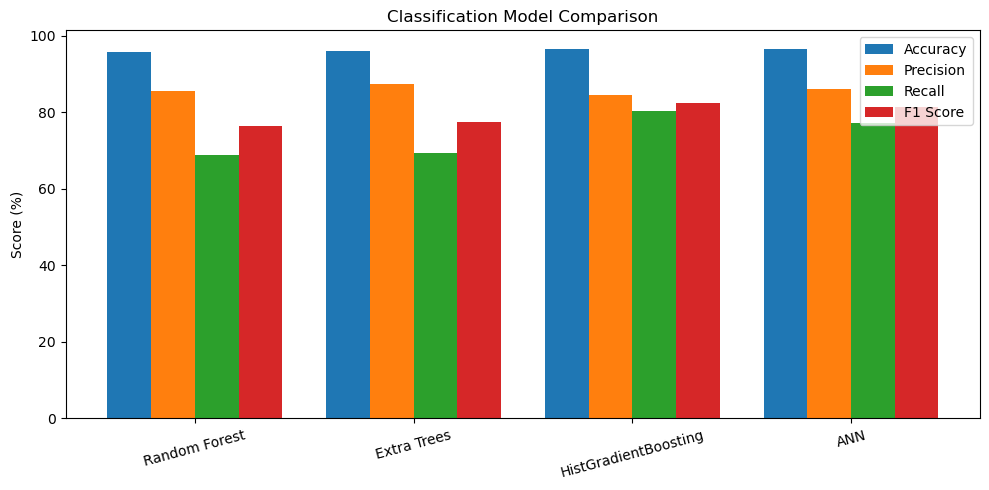

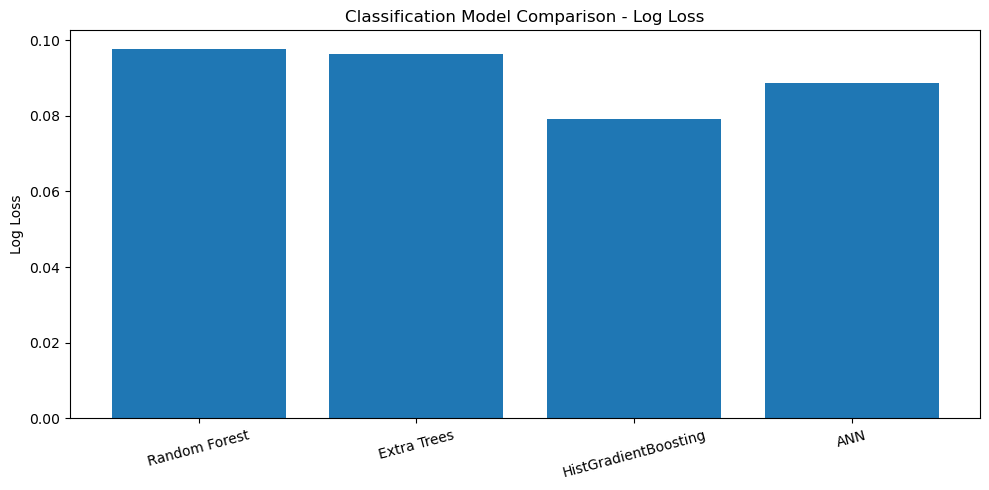

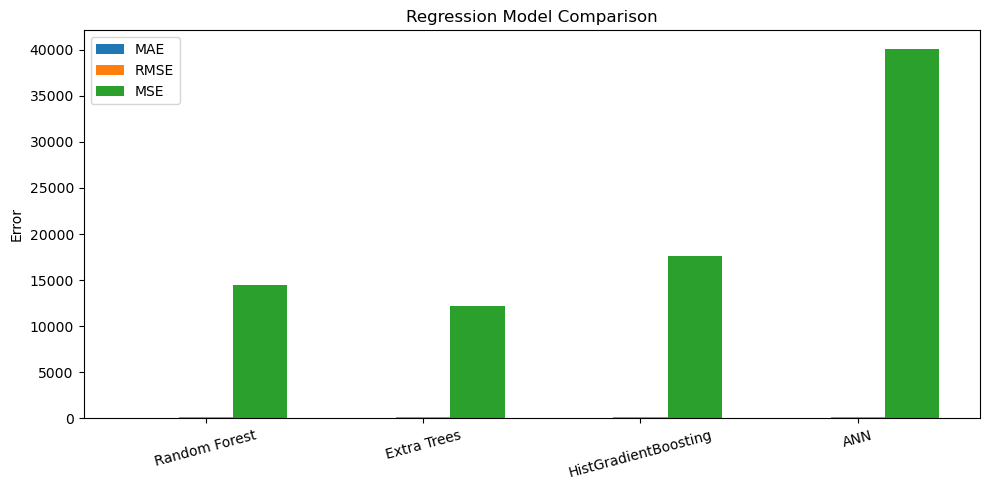

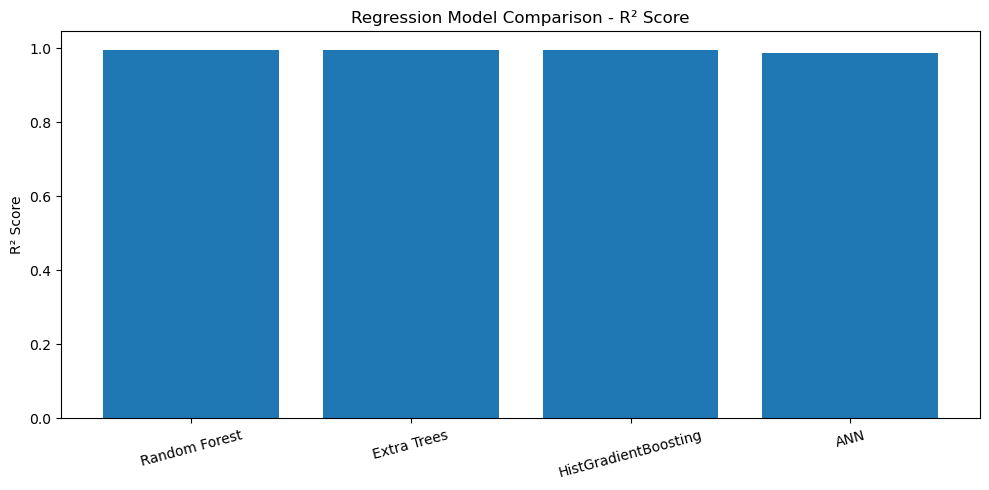

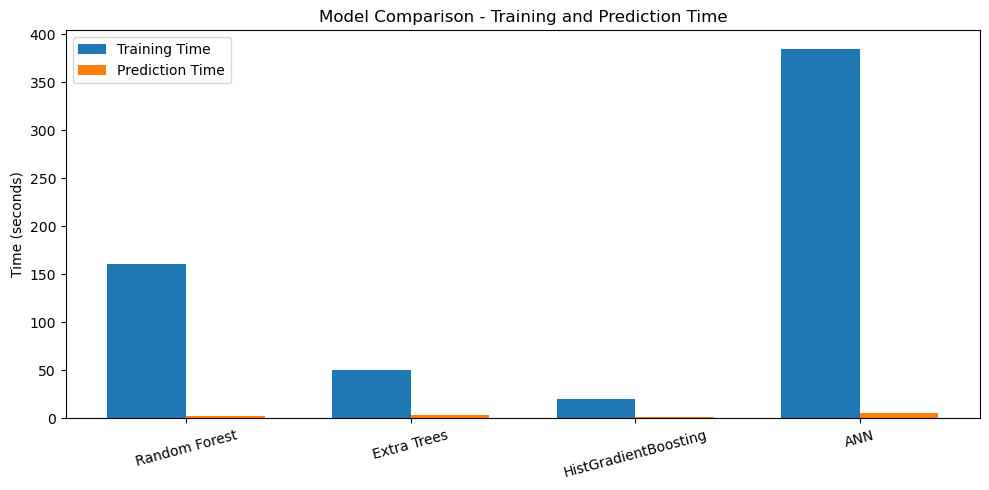

In [43]:
import matplotlib.pyplot as plt

models = final_model_comparison["Model"]

plt.figure(figsize=(10, 5))
x = range(len(models))
width = 0.2

plt.bar([i - 1.5 * width for i in x], final_model_comparison["Accuracy"] * 100, width, label="Accuracy")
plt.bar([i - 0.5 * width for i in x], final_model_comparison["Precision"] * 100, width, label="Precision")
plt.bar([i + 0.5 * width for i in x], final_model_comparison["Recall"] * 100, width, label="Recall")
plt.bar([i + 1.5 * width for i in x], final_model_comparison["F1 Score"] * 100, width, label="F1 Score")

plt.xticks(x, models, rotation=15)
plt.ylabel("Score (%)")
plt.title("Classification Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

plt.bar(models, final_model_comparison["Log Loss"])

plt.ylabel("Log Loss")
plt.title("Classification Model Comparison - Log Loss")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

x = range(len(models))
width = 0.25

plt.bar([i - width for i in x], final_model_comparison["MAE"], width, label="MAE")
plt.bar(x, final_model_comparison["RMSE"], width, label="RMSE")
plt.bar([i + width for i in x], final_model_comparison["MSE"], width, label="MSE")

plt.xticks(x, models, rotation=15)
plt.ylabel("Error")
plt.title("Regression Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

plt.bar(models, final_model_comparison["R2 Score"])

plt.ylabel("R² Score")
plt.title("Regression Model Comparison - R² Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

x = range(len(models))
width = 0.35

plt.bar([i - width / 2 for i in x], final_model_comparison["Training Time (s)"], width, label="Training Time")
plt.bar([i + width / 2 for i in x], final_model_comparison["Prediction Time (s)"], width, label="Prediction Time")

plt.xticks(x, models, rotation=15)
plt.ylabel("Time (seconds)")
plt.title("Model Comparison - Training and Prediction Time")
plt.legend()
plt.tight_layout()
plt.show()